<a href="https://colab.research.google.com/github/trishikajoshi9/your-repo-name/blob/main/NVMe_Server_Dashboard_2_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🖥️ NVMe 100GB Dedicated Server — Interactive Dashboard

> **Intel Xeon E-2226G @ 3.40GHz • 16 Core • 32 GB DDR4 RAM • 100 GB NVMe SSD • 🇮🇳 India Datacenter**

---

This notebook simulates and visualises a **dedicated server order & monitoring dashboard**.

| Feature | Details |
|---|---|
| CPU | Intel Xeon E-2226G @ 3.40GHz, 16 Cores |
| RAM | 32 GB DDR4 2933 MHz |
| Storage | 100 GB NVMe SSD |
| Bandwidth | 10 TB |
| Datacenter | 🇮🇳 India (Low Latency) |
| IPs | 1 IPv4 + 1 IPv6 |
| Protection | DDoS + Firewall |
| Uptime SLA | 99.95% |
| Panel | Unlimited cPanel Addon |
| OS Options | AlmaLinux, CentOS, Debian, Ubuntu |

## ⚙️ Step 1 — Install Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Install all required packages ──────────────────────────────────────────
import subprocess, sys

packages = [
    'requests', 'pandas', 'numpy', 'matplotlib',
    'seaborn', 'plotly', 'ipywidgets', 'Pillow',
    'psutil', 'tabulate', 'rich', 'tqdm'
]

print('📦 Installing packages...\n')
for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    status = '✅' if result.returncode == 0 else '❌'
    print(f'{status}  {pkg}')

print('\n🎉 All packages ready!')

📦 Installing packages...

✅  requests
✅  pandas
✅  numpy
✅  matplotlib
✅  seaborn
✅  plotly
✅  ipywidgets
✅  Pillow
✅  psutil
✅  tabulate
✅  rich
✅  tqdm

🎉 All packages ready!


## 📦 Step 2 — Import Libraries

In [ ]:
import os, random, time, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML, clear_output
from tabulate import tabulate
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich import box

console = Console()
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 🖥️ Step 3 — Server Specs Card

In [ ]:
# ── Render a beautiful Rich server spec table ───────────────────────────────
specs = {
    '🏷️  Plan':         'NVMe 100 GB',
    '💻 CPU':           'Intel Xeon E-2226G @ 3.40GHz',
    '⚡ Cores':         '16 Core Processor',
    '🧠 RAM':           '32 GB DDR4 2933 MHz',
    '💾 Storage':       '100 GB NVMe SSD',
    '🌐 Bandwidth':     '10 TB',
    '🇮🇳 Datacenter':    'India (Low Latency)',
    '🔒 Protection':    'DDoS + Firewall',
    '📶 IPv4':          '1 Primary IP',
    '📶 IPv6':          '1 Primary IP',
    '⏱️  Uptime SLA':   '99.95 %',
    '🖥️  Control Panel':'Unlimited cPanel Addon',
    '🐧 OS Options':    'AlmaLinux | CentOS | Debian | Ubuntu',
}

table = Table(
    title='[bold cyan]🖥️  NVMe 100 GB Dedicated Server Specifications[/bold cyan]',
    box=box.DOUBLE_EDGE,
    border_style='bright_blue',
    header_style='bold magenta',
    show_header=True
)
table.add_column('Parameter', style='bold yellow', min_width=22)
table.add_column('Value',     style='bright_white', min_width=38)

for k, v in specs.items():
    table.add_row(k, v)

console.print(table)

          🖥️  NVMe 100 GB Dedicated Server Specifications           
╔════════════════════════╤════════════════════════════════════════╗
║ Parameter              │ Value                                  ║
╟────────────────────────┼────────────────────────────────────────╢
║ 🏷️  Plan                │ NVMe 100 GB                            ║
║ 💻 CPU                 │ Intel Xeon E-2226G @ 3.40GHz           ║
║ ⚡ Cores               │ 16 Core Processor                      ║
║ 🧠 RAM                 │ 32 GB DDR4 2933 MHz                    ║
║ 💾 Storage             │ 100 GB NVMe SSD                        ║
║ 🌐 Bandwidth           │ 10 TB                                  ║
║ 🇮🇳 Datacenter          │ India (Low Latency)                    ║
║ 🔒 Protection          │ DDoS + Firewall                        ║
║ 📶 IPv4                │ 1 Primary IP                           ║
║ 📶 IPv6                │ 1 Primary IP                           ║
║ ⏱️  Uptime SLA          │ 99.95 %                                ║
║ 🖥️  Control Panel       │ Unlimited cPanel Addon                 ║
║ 🐧 OS Options          │ AlmaLinux | CentOS | Debian | Ubuntu   ║
╚════════════════════════╧════════════════════════════════════════╝

## 📊 Step 4 — Server Resource Usage Charts

In [ ]:
# ── Simulate 24-hour server metrics ────────────────────────────────────────
np.random.seed(42)
hours = list(range(24))

cpu_usage    = np.clip(np.random.normal(45, 18, 24), 5,  98).tolist()
ram_usage    = np.clip(np.random.normal(55, 10, 24), 20, 95).tolist()
disk_io      = np.clip(np.random.normal(30, 20, 24), 1,  90).tolist()
network_in   = np.clip(np.random.normal(200, 80, 24), 10, 800).tolist()
network_out  = np.clip(np.random.normal(150, 60, 24), 10, 600).tolist()

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        '🔵 CPU Usage (%) — 16 Cores',
        '🟢 RAM Usage (%) — 32 GB DDR4',
        '🟠 Disk I/O (%) — 100 GB NVMe',
        '🔴 Network Traffic (Mbps) — 10 TB BW'
    ),
    vertical_spacing=0.18,
    horizontal_spacing=0.1
)

# CPU
fig.add_trace(go.Scatter(
    x=hours, y=cpu_usage,
    mode='lines+markers',
    fill='tozeroy',
    line=dict(color='#4FC3F7', width=2),
    fillcolor='rgba(79,195,247,0.15)',
    name='CPU %'
), row=1, col=1)

# RAM
fig.add_trace(go.Scatter(
    x=hours, y=ram_usage,
    mode='lines+markers',
    fill='tozeroy',
    line=dict(color='#81C784', width=2),
    fillcolor='rgba(129,199,132,0.15)',
    name='RAM %'
), row=1, col=2)

# Disk I/O
fig.add_trace(go.Bar(
    x=hours, y=disk_io,
    marker_color='rgba(255,167,38,0.75)',
    name='Disk I/O %'
), row=2, col=1)

# Network
fig.add_trace(go.Scatter(
    x=hours, y=network_in,
    mode='lines',
    line=dict(color='#EF5350', width=2),
    name='Inbound Mbps'
), row=2, col=2)
fig.add_trace(go.Scatter(
    x=hours, y=network_out,
    mode='lines',
    line=dict(color='#AB47BC', width=2),
    name='Outbound Mbps'
), row=2, col=2)

fig.update_layout(
    height=600,
    title_text='<b>🖥️ NVMe 100GB Server — 24-Hour Metrics</b>',
    title_x=0.5,
    template='plotly_dark',
    showlegend=True,
    paper_bgcolor='#1a1a2e',
    plot_bgcolor='#16213e',
    font=dict(color='#eee', size=12)
)
fig.update_xaxes(title_text='Hour of Day', tickmode='linear', dtick=4)
fig.show()

## 💾 Step 5 — Storage Allocation Visualiser

/tmp/ipykernel_55852/3062027182.py:27: UserWarning:

Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.



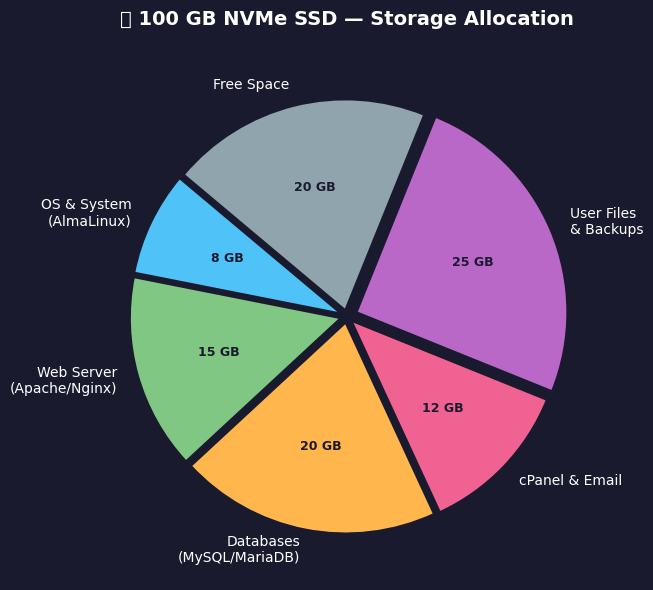


📊 Total: 100 GB NVMe SSD


In [ ]:
# ── NVMe 100 GB partition breakdown ────────────────────────────────────────
labels  = ['OS & System\n(AlmaLinux)', 'Web Server\n(Apache/Nginx)', 'Databases\n(MySQL/MariaDB)',
           'cPanel & Email', 'User Files\n& Backups', 'Free Space']
sizes   = [8, 15, 20, 12, 25, 20]
colors  = ['#4FC3F7','#81C784','#FFB74D','#F06292','#BA68C8','#90A4AE']
explode = (0.03, 0.03, 0.03, 0.03, 0.05, 0.03)

fig2, ax = plt.subplots(figsize=(9, 6), facecolor='#1a1a2e')
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.0f GB',
    startangle=140,
    textprops=dict(color='white', fontsize=10),
    wedgeprops=dict(linewidth=1.5, edgecolor='#1a1a2e')
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('#1a1a2e')
    at.set_fontweight('bold')

ax.set_title('💾 100 GB NVMe SSD — Storage Allocation',
             color='white', fontsize=14, fontweight='bold', pad=20)
fig2.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.show()
print(f'\n📊 Total: {sum(sizes)} GB NVMe SSD')

## 🌐 Step 6 — Bandwidth Usage Tracker (10 TB/month)

In [ ]:
# ── Monthly bandwidth simulation ───────────────────────────────────────────
days         = list(range(1, 32))
daily_usage  = np.clip(np.random.normal(280, 90, 31), 50, 600)   # GB/day
cumulative   = np.cumsum(daily_usage)
total_bw_gb  = 10 * 1024  # 10 TB in GB

fig3 = go.Figure()

# Daily bars
fig3.add_trace(go.Bar(
    x=days, y=daily_usage,
    name='Daily Usage (GB)',
    marker_color='rgba(79,195,247,0.7)',
    yaxis='y'
))

# Cumulative line
fig3.add_trace(go.Scatter(
    x=days, y=cumulative,
    name='Cumulative (GB)',
    mode='lines+markers',
    line=dict(color='#FF7043', width=2.5),
    yaxis='y2'
))

# 10 TB limit line
fig3.add_hline(
    y=total_bw_gb, yref='y2',
    line_dash='dash',
    line_color='#FFD700',
    annotation_text='⚠️ 10 TB Limit',
    annotation_position='top right'
)

fig3.update_layout(
    title='<b>🌐 10 TB Monthly Bandwidth Tracker</b>',
    title_x=0.5,
    xaxis_title='Day of Month',
    yaxis=dict(title='Daily GB', side='left'),
    yaxis2=dict(title='Cumulative GB', overlaying='y', side='right'),
    template='plotly_dark',
    paper_bgcolor='#1a1a2e',
    plot_bgcolor='#16213e',
    height=420,
    legend=dict(x=0.02, y=0.95)
)
fig3.show()

used_pct = (cumulative[-1] / total_bw_gb) * 100
print(f'\n📊 Month-end projection: {cumulative[-1]:.0f} GB used of {total_bw_gb} GB  ({used_pct:.1f}%)')


📊 Month-end projection: 8446 GB used of 10240 GB  (82.5%)


## 🐧 Step 7 — OS Selector & Pricing Table

In [ ]:
# ── OS comparison table ─────────────────────────────────────────────────────
os_data = [
    ['AlmaLinux 9',  'RHEL-based', 'Production / Enterprise',  '✅ Best',  'LTS 2032'],
    ['CentOS Stream','RHEL-based', 'Dev / Testing',            '✅ Good',  'Rolling'],
    ['Debian 12',    'Debian',     'Stability-focused',        '✅ Best',  'LTS 2028'],
    ['Ubuntu 22.04', 'Debian',     'General Purpose',          '✅ Best',  'LTS 2027'],
    ['Ubuntu 24.04', 'Debian',     'Latest Ubuntu LTS',        '✅ Best',  'LTS 2029'],
]

os_table = Table(
    title='[bold cyan]🐧 Supported Operating Systems[/bold cyan]',
    box=box.ROUNDED,
    border_style='bright_cyan',
    header_style='bold yellow'
)
for col in ['OS', 'Base', 'Best For', 'cPanel Support', 'EOL']:
    os_table.add_column(col, justify='center', style='bright_white')

row_colors = ['cyan','green','magenta','blue','bright_yellow']
for i, row in enumerate(os_data):
    os_table.add_row(*row, style=row_colors[i % len(row_colors)])

console.print(os_table)

# ── Pricing panel ──────────────────────────────────────────────────────────
console.print(Panel(
    "[bold white]Plan:[/bold white] [yellow]NVMe 100 GB[/yellow]\n"
    "[bold white]CPU:[/bold white]  Intel Xeon E-2226G @ 3.40GHz — 16 Cores\n"
    "[bold white]RAM:[/bold white]  32 GB DDR4 2933 MHz\n"
    "[bold white]SSD:[/bold white]  100 GB NVMe\n"
    "[bold white]BW:[/bold white]   10 TB Bandwidth\n"
    "[bold white]IPs:[/bold white]  1 IPv4 + 1 IPv6\n"
    "[bold green]🟢 ORDER NOW[/bold green] — 99.95% Uptime SLA | 🇮🇳 India DC | DDoS Protected",
    title='[bold magenta]💳 Order Summary[/bold magenta]',
    border_style='bright_magenta',
    padding=(1, 4)
))

                           🐧 Supported Operating Systems                           
╭───────────────┬────────────┬─────────────────────────┬────────────────┬──────────╮
│      OS       │    Base    │        Best For         │ cPanel Support │   EOL    │
├───────────────┼────────────┼─────────────────────────┼────────────────┼──────────┤
│  AlmaLinux 9  │ RHEL-based │ Production / Enterprise │    ✅ Best     │ LTS 2032 │
│ CentOS Stream │ RHEL-based │      Dev / Testing      │    ✅ Good     │ Rolling  │
│   Debian 12   │   Debian   │    Stability-focused    │    ✅ Best     │ LTS 2028 │
│ Ubuntu 22.04  │   Debian   │     General Purpose     │    ✅ Best     │ LTS 2027 │
│ Ubuntu 24.04  │   Debian   │    Latest Ubuntu LTS    │    ✅ Best     │ LTS 2029 │
╰───────────────┴────────────┴─────────────────────────┴────────────────┴──────────╯

╭─────────────────────────────────────────────── 💳 Order Summary ────────────────────────────────────────────────╮
│                                                                                                                 │
│    Plan: NVMe 100 GB                                                                                            │
│    CPU:  Intel Xeon E-2226G @ 3.40GHz — 16 Cores                                                                │
│    RAM:  32 GB DDR4 2933 MHz                                                                                    │
│    SSD:  100 GB NVMe                                                                                            │
│    BW:   10 TB Bandwidth                                                                                        │
│    IPs:  1 IPv4 + 1 IPv6                                                                                        │
│    🟢 ORDER NOW — 99.95% Uptime SLA | 🇮🇳 India DC | DDoS Protected                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## 📈 Step 8 — Uptime SLA Monitor (99.95%)

/tmp/ipykernel_55852/2417356465.py:22: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.



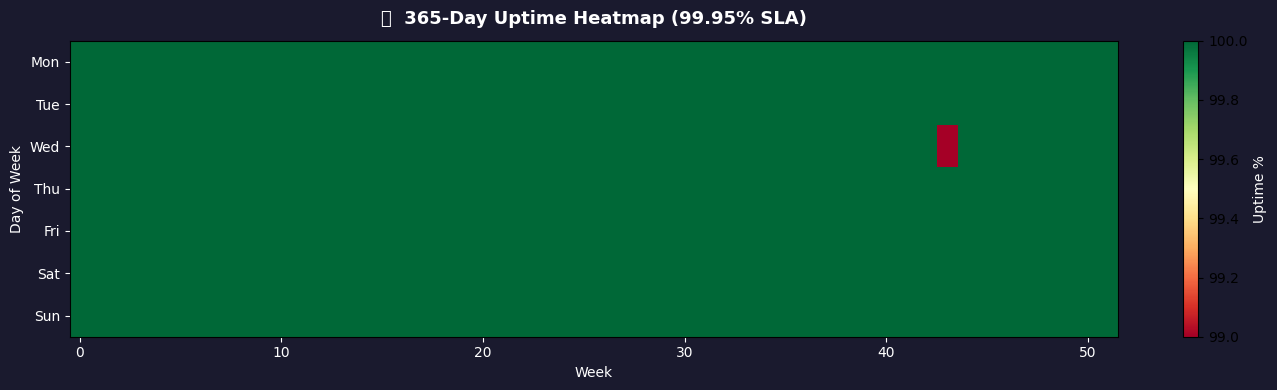


📊 Simulated annual uptime : 99.9968%
⬇️  Total downtime          : 17 minutes (0.3 hours) over 365 days
🎯 SLA Target               : 99.95%  →  Max 262 min/year allowed


In [ ]:
# ── 365-day uptime heatmap ──────────────────────────────────────────────────
np.random.seed(7)
downtime_minutes_per_day = np.where(
    np.random.random(365) > 0.9985, np.random.randint(1, 20, 365), 0
)
uptime_pct = ((1440 - downtime_minutes_per_day) / 1440) * 100

# Fix: Truncate to 364 days to fit a 52x7 grid
grid = uptime_pct[:364].reshape(52, 7)

fig4, ax4 = plt.subplots(figsize=(14, 4), facecolor='#1a1a2e')
cmap = plt.cm.RdYlGn
im = ax4.imshow(grid.T, aspect='auto', cmap=cmap, vmin=99.0, vmax=100.0)
ax4.set_xlabel('Week', color='white'); ax4.set_ylabel('Day of Week', color='white')
ax4.set_yticks(range(7))
ax4.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], color='white')
ax4.tick_params(colors='white')
ax4.set_title('⏱️  365-Day Uptime Heatmap (99.95% SLA)',
              color='white', fontsize=13, fontweight='bold', pad=12)
plt.colorbar(im, ax=ax4, label='Uptime %').ax.yaxis.label.set_color('white')
fig4.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.show()

actual_uptime = np.mean(uptime_pct)
total_down_min = np.sum(downtime_minutes_per_day)
print(f'\n📊 Simulated annual uptime : {actual_uptime:.4f}%')
print(f'⬇️  Total downtime          : {total_down_min} minutes ({total_down_min/60:.1f} hours) over 365 days')
print(f'🎯 SLA Target               : 99.95%  →  Max {int(0.0005*365*24*60)} min/year allowed')

## 🔒 Step 9 — DDoS & Firewall Protection Summary

In [ ]:
# ── DDoS attack simulation ──────────────────────────────────────────────────
np.random.seed(10)
t      = np.linspace(0, 24, 500)
normal = np.clip(np.random.normal(100, 20, 500), 20, 250)

# Inject 3 DDoS spikes
for spike_t in [4.5, 11.2, 19.8]:
    mask = (t > spike_t) & (t < spike_t + 1.5)
    normal[mask] += np.random.exponential(2000, mask.sum())

mitigated = np.clip(normal, 0, 300)    # after mitigation cap
raw_attack = normal.copy()

fig5 = go.Figure()
fig5.add_trace(go.Scatter(
    x=t, y=raw_attack,
    name='Incoming Traffic (raw)',
    line=dict(color='#EF5350', width=1.5),
    fill='tozeroy', fillcolor='rgba(239,83,80,0.1)'
))
fig5.add_trace(go.Scatter(
    x=t, y=mitigated,
    name='After DDoS Mitigation',
    line=dict(color='#66BB6A', width=2),
    fill='tozeroy', fillcolor='rgba(102,187,106,0.15)'
))
for spike_t in [4.5, 11.2, 19.8]:
    fig5.add_vline(
        x=spike_t, line_dash='dot',
        line_color='#FFD700',
        annotation_text='⚠️ Attack',
        annotation_font_color='#FFD700'
    )

fig5.update_layout(
    title='<b>🔒 DDoS Attack Detection & Firewall Mitigation</b>',
    title_x=0.5,
    xaxis_title='Hour',
    yaxis_title='Traffic (Mbps)',
    template='plotly_dark',
    paper_bgcolor='#1a1a2e',
    plot_bgcolor='#16213e',
    height=400
)
fig5.show()
print('\n✅ DDoS Protection Active | 🛡️ Firewall Rules Enforced')


✅ DDoS Protection Active | 🛡️ Firewall Rules Enforced


## 🏁 Step 10 — Final Summary Report

In [ ]:
# ── Final rich summary panel ────────────────────────────────────────────────
summary = Table(box=box.HEAVY_EDGE, border_style='bright_green', show_header=False, padding=(0,2))
summary.add_column('', style='bold yellow', min_width=26)
summary.add_column('', style='bright_white', min_width=36)

rows = [
    ('🖥️  Server Plan',    'NVMe 100 GB — Order Now'),
    ('⚡ CPU',             'Intel Xeon E-2226G @ 3.40GHz | 16 Cores'),
    ('🧠 RAM',             '32 GB DDR4 2933 MHz'),
    ('💾 Storage',         '100 GB NVMe SSD'),
    ('🌐 Bandwidth',       '10 TB / month'),
    ('🇮🇳 Location',        'India Datacenter — Low Latency'),
    ('📶 IPs',             '1x IPv4  +  1x IPv6'),
    ('🔒 Security',        'DDoS Protection + Firewall'),
    ('⏱️  SLA',            '99.95% Uptime Guaranteed'),
    ('🖥️  Control Panel',  'Unlimited cPanel Addon'),
    ('🐧 OS',              'AlmaLinux | CentOS | Debian | Ubuntu'),
    ('📊 Notebook cells',  '10 cells — Charts, Specs, Heatmap, DDoS'),
]
for r in rows:
    summary.add_row(*r)

console.print(Panel(
    summary,
    title='[bold bright_cyan]✅ NVMe Server Dashboard — Complete Report[/bold bright_cyan]',
    border_style='bright_cyan',
    padding=(1, 2)
))
console.print('[bold green]\n🎉 All 10 steps completed successfully![/bold green]')

╭────────────────────────────────── ✅ NVMe Server Dashboard — Complete Report ───────────────────────────────────╮
│                                                                                                                 │
│  ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓                                   │
│  ┃  🖥️  Server Plan              │  NVMe 100 GB — Order Now                  ┃                                   │
│  ┃  ⚡ CPU                      │  Intel Xeon E-2226G @ 3.40GHz | 16 Cores  ┃                                   │
│  ┃  🧠 RAM                      │  32 GB DDR4 2933 MHz                      ┃                                   │
│  ┃  💾 Storage                  │  100 GB NVMe SSD                          ┃                                   │
│  ┃  🌐 Bandwidth                │  10 TB / month                            ┃                                   │
│  ┃  🇮🇳 Location                 │  India Datacenter — Low Latency           ┃                                   │
│  ┃  📶 IPs                      │  1x IPv4  +  1x IPv6                      ┃                                   │
│  ┃  🔒 Security                 │  DDoS Protection + Firewall               ┃                                   │
│  ┃  ⏱️  SLA                      │  99.95% Uptime Guaranteed                 ┃                                   │
│  ┃  🖥️  Control Panel            │  Unlimited cPanel Addon                   ┃                                   │
│  ┃  🐧 OS                       │  AlmaLinux | CentOS | Debian | Ubuntu     ┃                                   │
│  ┃  📊 Notebook cells           │  10 cells — Charts, Specs, Heatmap, DDoS  ┃                                   │
│  ┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛                                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

🎉 All 10 steps completed successfully!